# 01. Data Cleaning and Exploration

This notebook defines the historical good/bad target, makes the selected repairs explicit, and checks the resulting portfolio.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

DATA_PATH = Path('../data/loan_data_2007_2014.csv')
BAD_STATUSES = {
    'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)',
}

def load_and_clean():
    data = pd.read_csv(DATA_PATH, low_memory=False)
    required = ['loan_status', 'emp_length', 'term', 'earliest_cr_line', 'issue_d',
                'annual_inc', 'funded_amnt', 'total_rev_hi_lim', 'grade', 'int_rate', 'dti']
    missing = sorted(set(required) - set(data.columns))
    if missing:
        raise ValueError(f'Missing required columns: {missing}')
    data['good_bad'] = (~data['loan_status'].isin(BAD_STATUSES)).astype(int)
    data['emp_length_int'] = data['emp_length'].str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
    data['term_int'] = data['term'].str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
    for column in ['earliest_cr_line', 'issue_d']:
        dates = pd.to_datetime(data[column], format='%b-%y', errors='coerce')
        data[f'{column}_date'] = dates
        data[f'mths_since_{column}'] = ((pd.Timestamp('2017-12-01') - dates).dt.days / 30.4375).round()
    data['total_rev_hi_lim'] = data['total_rev_hi_lim'].fillna(data['funded_amnt'])
    data['annual_inc'] = data['annual_inc'].fillna(data['annual_inc'].median())
    for column in ['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq']:
        if column in data:
            data[column] = data[column].fillna(0)
    return data

Matplotlib is building the font cache; this may take a moment.


In [2]:
clean_data = load_and_clean()
clean_data[['loan_status', 'good_bad', 'emp_length', 'emp_length_int', 'term', 'term_int']].head()

,loan_status,good_bad,emp_length,emp_length_int,term,term_int
0,Fully Paid,1,10+ years,10,36 months,36
1,Charged Off,0,< 1 year,1,60 months,60
2,Fully Paid,1,10+ years,10,36 months,36
3,Fully Paid,1,10+ years,10,36 months,36
4,Current,1,1 year,1,60 months,60


## Target definition and missing-value handling

`good_bad = 0` marks the listed historical bad statuses; every other status is treated as good standing. This is an educational historical label, not a current lending decision.

In [3]:
pd.DataFrame({
    'missing_after_cleaning': clean_data[['annual_inc', 'total_rev_hi_lim', 'emp_length_int', 'term_int']].isna().sum(),
    'dtype': clean_data[['annual_inc', 'total_rev_hi_lim', 'emp_length_int', 'term_int']].dtypes.astype(str),
})

,missing_after_cleaning,dtype
annual_inc,0,float64
total_rev_hi_lim,0,float64
emp_length_int,0,int64
term_int,0,int64


In [4]:
clean_data[['mths_since_earliest_cr_line', 'mths_since_issue_d']].describe().T
clean_data['good_bad'].value_counts(normalize=True).rename('share').to_frame()

,share
good_bad,
1,0.890693
0,0.109307


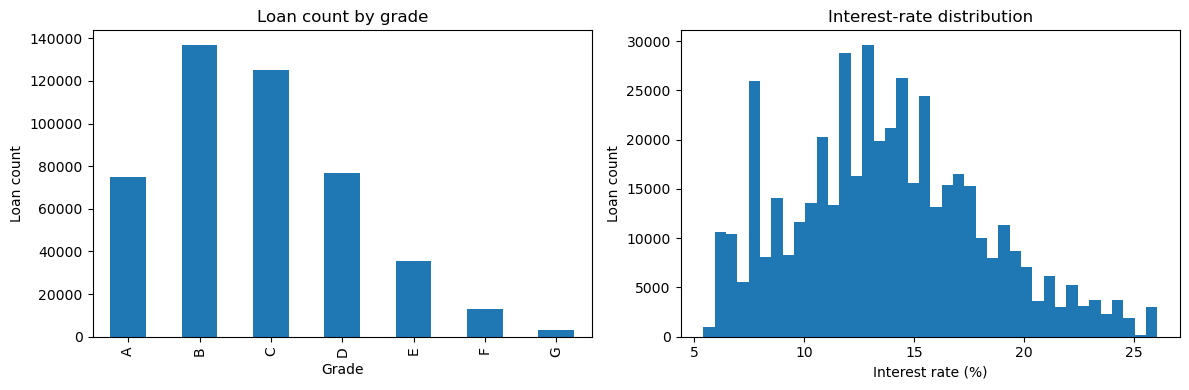

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
clean_data['grade'].value_counts().sort_index().plot.bar(ax=axes[0], title='Loan count by grade')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Loan count')
clean_data['int_rate'].plot.hist(ax=axes[1], bins=40, title='Interest-rate distribution')
axes[1].set_xlabel('Interest rate (%)')
axes[1].set_ylabel('Loan count')
fig.tight_layout()

## Conclusions

The target, employment length, term, and dates are now numeric or explicitly labelled. Notebook 02 turns the selected borrower attributes into coarse classes and reviews their WoE/IV.